# Supervised Learning 

## Preparing and shaping the data

In [1]:
import pandas as pd 
import numpy as np 

print("libraries import successfully")

libraries import successfully


### Load the dataset of titanic 


In [2]:
data = pd.read_csv("tested.csv")
print("Data Loaded Successfully")
data.head()

Data Loaded Successfully


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [3]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 39.3 KB


In [5]:
data['Travelalone'] = np.where(data['SibSp'] + data['Parch'] > 0,0,1).astype('uint8')

In [6]:
df1 = data.drop(['PassengerId', 'Name', 'SibSp', 'Parch', 'Ticket', 'Cabin'] , axis = 1)

In [7]:
df1.isna().sum()
data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
Travelalone      0
dtype: int64

In [8]:
data['Age'].fillna(df1['Age'].median(skipna=True), inplace=True)

C:\Users\shekh\AppData\Local\Temp\ipykernel_28320\1210681425.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['Age'].fillna(df1['Age'].median(skipna=True), inplace=True)


0      34.5
1      47.0
2      62.0
3      27.0
4      22.0
       ... 
413    27.0
414    39.0
415    38.5
416    27.0
417    27.0
Name: Age, Length: 418, dtype: float64

In [9]:
df1.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Travelalone
0,0,3,male,34.5,7.8292,Q,1
1,1,3,female,47.0,7.0000,S,0
2,0,2,male,62.0,9.6875,Q,1
3,0,3,male,27.0,8.6625,S,1
4,1,3,female,22.0,12.2875,S,0


In [10]:
df_titanic = pd.get_dummies(df1, columns=['Pclass', 'Embarked', 'Sex'], drop_first=True)
df_titanic.head()

,Survived,Age,Fare,Travelalone,Pclass_2,Pclass_3,Embarked_Q,Embarked_S,Sex_male
0,0,34.5,7.8292,1,False,True,True,False,True
1,1,47.0,7.0000,0,False,True,False,True,False
2,0,62.0,9.6875,1,True,False,True,False,True
3,0,27.0,8.6625,1,False,True,False,True,True
4,1,22.0,12.2875,0,False,True,False,True,False


In [11]:
x = df_titanic.drop(['Survived'], axis=1)
y = df_titanic['Survived']

In [12]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [13]:
mm = MinMaxScaler()
ss = StandardScaler()

# MinMaxScaler

In [14]:
df_mm = mm.fit_transform(x)
pd.DataFrame(df_mm)

,0,1,2,3,4,5,6,7
0,0.452723,0.015282,1.0,0.0,1.0,1.0,0.0,1.0
1,0.617566,0.013663,0.0,0.0,1.0,0.0,1.0,0.0
2,0.815377,0.018909,1.0,1.0,0.0,1.0,0.0,1.0
3,0.353818,0.016908,1.0,0.0,1.0,0.0,1.0,1.0
4,0.287881,0.023984,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...
413,NaN,0.015713,1.0,0.0,1.0,0.0,1.0,1.0
414,0.512066,0.212559,1.0,0.0,0.0,0.0,0.0,0.0
415,0.505473,0.014151,1.0,0.0,1.0,0.0,1.0,1.0
416,NaN,0.015713,1.0,0.0,1.0,0.0,1.0,1.0


### Standard Scaler

In [15]:
df_ss = ss.fit_transform(x)
pd.DataFrame(df_ss)

,0,1,2,3,4,5,6,7
0,0.298549,-0.497811,0.807573,-0.534933,0.957826,2.843757,-1.350676,0.755929
1,1.181328,-0.512660,-1.238278,-0.534933,0.957826,-0.351647,0.740370,-1.322876
2,2.240662,-0.464532,0.807573,1.869391,-1.044031,2.843757,-1.350676,0.755929
3,-0.231118,-0.482888,0.807573,-0.534933,0.957826,-0.351647,0.740370,0.755929
4,-0.584229,-0.417971,-1.238278,-0.534933,0.957826,-0.351647,0.740370,-1.322876
...,...,...,...,...,...,...,...,...
413,NaN,-0.493856,0.807573,-0.534933,0.957826,-0.351647,0.740370,0.755929
414,0.616350,1.312180,0.807573,-0.534933,-1.044031,-0.351647,-1.350676,-1.322876
415,0.581038,-0.508183,0.807573,-0.534933,0.957826,-0.351647,0.740370,0.755929
416,NaN,-0.493856,0.807573,-0.534933,0.957826,-0.351647,0.740370,0.755929


# Overfitting & Underfitting


Defines how machine learning models are learning and applying what they learned.

Let understand the terms: Bias and varience

- Bias -> Bias is an error introduced in the model, High bias is big difference btween the actual and predicted values, this is bad for model. Low bias indicated that the difference between the actual and predicted values is low.

- Variance -> It indicates how scattered data is. High varience indicated more scatterd data and low varience indicates less scattered data.

### Overfitting:
It indicates a low bias and high variance in the data. Overfitting happens when a model focuses on too many details in the raining dataset.(has a negative impact on the performance of the model on a new dataset)

### Underfitting
Underfitting is a condition where a model is too simple to learn the underlying pattern of the data, resulting in poor performance on both training and test datasets.

## Note ->

- Model prform well with trainig and testing data is called good model.
- Model perform well with training but not testing is called overfit model.
- Model does not perform well with training and testing data is called underfit model.

### How detects the under and overfitting ?

In [25]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt 


In [ ]:
X, y = make_classification(n_samples = 9000, n_features=18, n_informative=4, n_redundant=12, random_state=4)

'''
1. n_samples: The total number or rows in the dataset. in this sample dataset we have 9000 rows.
2. n_features: The total number of columns in the dataset. in this sample dataset we have 18 columns.
3. n_informative: The number of features that are actually useful for predicting the target variable. in this sample dataset we have 4 informative features.
4. n_redundant: The number of features that are generated as random linear combinations of the informative features. in this sample dataset we have 12 redundant features.
   ex = If informative features are A, B, C, D and then redundant features can be generates as E = A + B, F = B + C, G = A * B.
   these new features are not independent, these are derived from the informative features.
5. random_state: A seed value to ensure reproducibility of the dataset. in this sample dataset we have set the random state to 4, which means that every time we run the code, we will get the same dataset.
'''

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3) # Here we have 70% data is used for training and 30% data is used for testing the model.

# Empty list to store the score of the model.
train_scores, test_scores = list(),list()

values = [i for i in range(1,21)] # Here we do test the depth of the tree from 2 to 20.

for i in values:
    model = DecisionTreeClassifier(max_depth=i)
    model.fit(X_train, y_train)  # X_train is the input features and y_train is the target lables. Here Model learns patterns from the training dataset.
    train_yhat = model.predict(X_train) # Model make predictions on the training dataset and store the predicted values in train_yhat.
    train_acc = accuracy_score(y_train, train_yhat) # Here we calculate the accuracy of training dataset by comparing the actual labels (y_train) with the predicted labels (train_yhat) and store the accuracy in train_acc.
    # accuracy = (correction predictions / total predictions).
    test_yhat = model.predict(X_test) # Here model prediction on the testing dataset and store the predicted values in test_yhat.
    test_acc = accuracy_score(y_test, test_yhat) # Here we calculate the accuracy of testing dataset by comparing the actual labels (y_test) with the predicted labels (test_yhat) and store the accuracy in test_acc.
    train_scores.append(train_acc)
    test_scores.append(test_acc)
    print('>%d train: %.3f, test: %.3f' % (i, train_acc, test_acc))
    

>1 train: 0.836, test: 0.836
>2 train: 0.849, test: 0.855
>3 train: 0.868, test: 0.863
>4 train: 0.892, test: 0.886
>5 train: 0.915, test: 0.906
>6 train: 0.931, test: 0.909
>7 train: 0.950, test: 0.929
>8 train: 0.961, test: 0.929
>9 train: 0.970, test: 0.935
>10 train: 0.976, test: 0.937
>11 train: 0.981, test: 0.939
>12 train: 0.986, test: 0.936
>13 train: 0.989, test: 0.936
>14 train: 0.993, test: 0.935
>15 train: 0.996, test: 0.932
>16 train: 0.998, test: 0.933
>17 train: 0.999, test: 0.935
>18 train: 1.000, test: 0.935
>19 train: 1.000, test: 0.936
>20 train: 1.000, test: 0.934


#### Train and Test score for different path

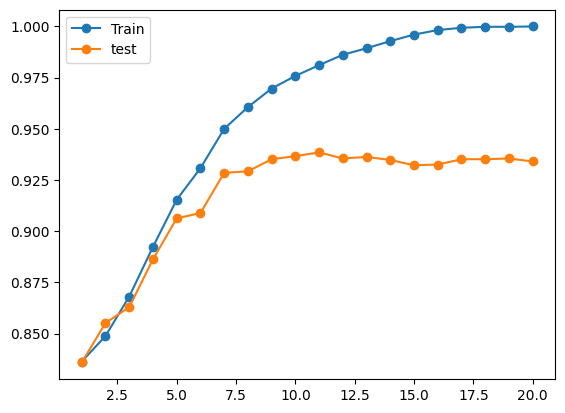

In [26]:
plt.plot(values, train_scores, '-o', label='Train' )
plt.plot(values, test_scores, '-o', label='test')
plt.legend()
plt.show()

This graph shows how Decision Tree coplexity affects model performance. At low  depth the model underfits, in the middle it achieves optimal performance, and at high hdepth it overfits the training data.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {'criterion': ['gini', 'entropy'], 'max_depth': [2,4,6,10,20], 'min_samples_split': [5, 10, 20, 50,100]}
